# 📈 Sales / Demand Forecasting using Machine Learning

## Capstone Project 3

### 🎯 Objective

The objective of this project is to analyze historical sales data, identify trends and seasonal patterns, and build a forecasting model that can predict future sales.

Forecasting helps businesses optimize inventory, improve demand planning, reduce operational costs, and make data-driven business decisions.

### Machine Learning Technique

- Time Series Analysis
- Linear Regression Forecasting

### Libraries Used

- Pandas
- NumPy
- Matplotlib
- Scikit-learn

# 📦 Import Required Libraries

Import the necessary Python libraries for data analysis, visualization, and forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


# 📂 Load Dataset

Load the sales dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv("train.csv")
print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [3]:
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
df.shape

(3000888, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [6]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


# 🔍 Exploratory Data Analysis

Explore the dataset to understand its structure, detect missing values, and prepare it for forecasting.

In [7]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')

In [10]:
df.head(10)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


# 📊 Step 5: Time-Based Data Visualization

In this step, we analyze sales over time to identify trends and patterns.

In [11]:
df["date"] = pd.to_datetime(df["date"])

print("✅ Date column converted successfully!")

✅ Date column converted successfully!


In [12]:
df.dtypes

id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

In [13]:
daily_sales = df.groupby("date")["sales"].sum()

daily_sales.head()

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

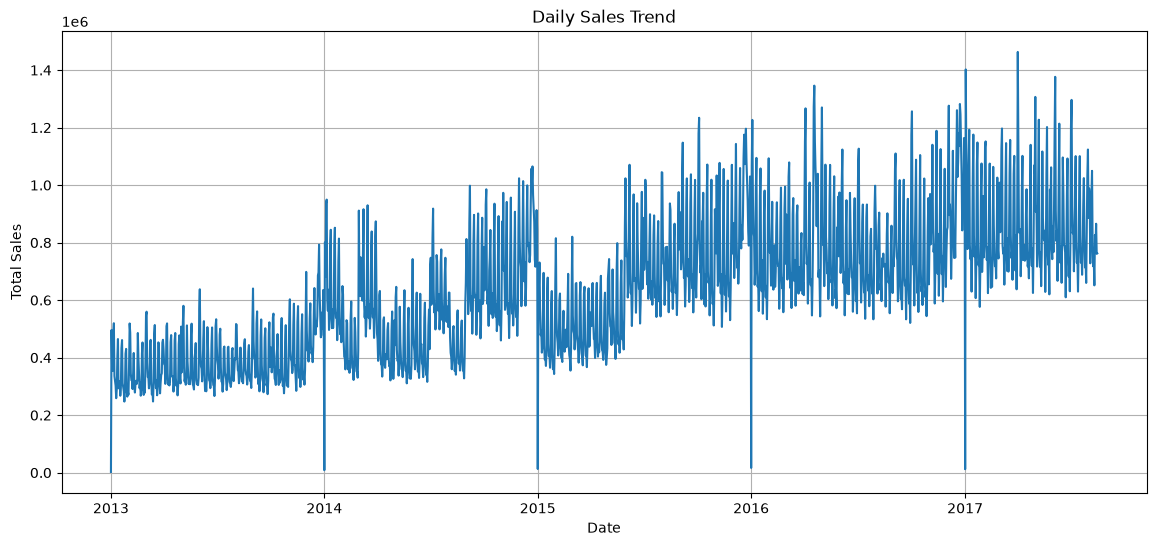

In [14]:
plt.figure(figsize=(14,6))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

# 📅 Step 6: Date Feature Engineering

Extract useful date-based features that help the forecasting model understand time patterns.

In [15]:
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["Day"] = df["date"].dt.day
df["DayOfWeek"] = df["date"].dt.dayofweek

print("✅ Date Features Created Successfully!")

✅ Date Features Created Successfully!


In [16]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,Year,Month,Day,DayOfWeek
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1


# 📈 Step 7: Monthly Sales Analysis

Analyze total sales for each month to identify long-term trends.

In [17]:
monthly_sales = df.groupby("Month")["sales"].sum()

monthly_sales

Month
1     9.444215e+07
2     8.063723e+07
3     9.722849e+07
4     9.066812e+07
5     9.439914e+07
6     9.451670e+07
7     1.033631e+08
8     8.347238e+07
9     7.747368e+07
10    8.008038e+07
11    8.033579e+07
12    9.702784e+07
Name: sales, dtype: float64

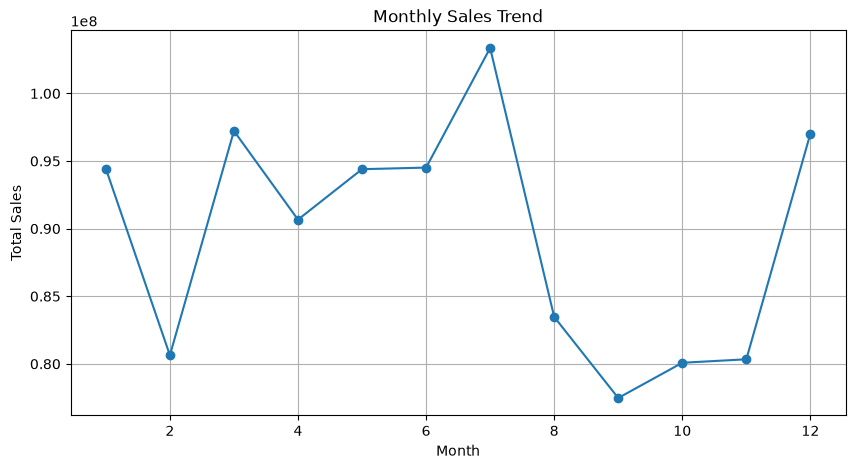

In [18]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

# 🌦 Step 8: Day of Week Sales Analysis

Analyze sales across different days of the week to identify weekly demand patterns.

In [19]:
weekday_sales = df.groupby("DayOfWeek")["sales"].mean()

weekday_sales

DayOfWeek
0    346.544732
1    319.823843
2    332.909401
3    283.540517
4    325.238138
5    433.336472
6    463.085366
Name: sales, dtype: float64

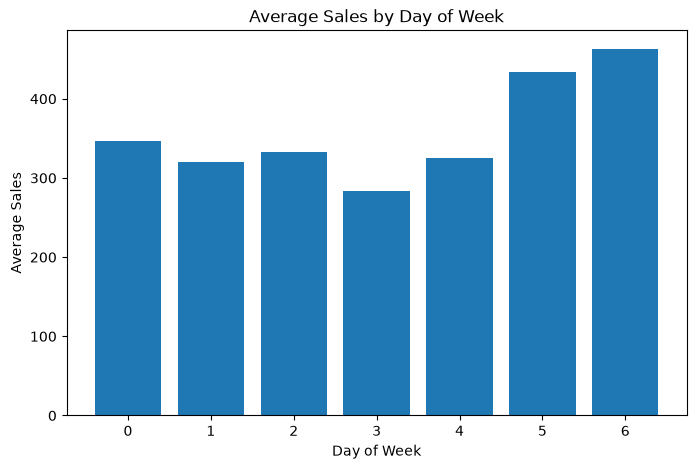

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    weekday_sales.index,
    weekday_sales.values
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.show()

# 🤖 Step 9: Prepare Data for Forecasting

Select the numerical date features to train a forecasting model.

In [21]:
X = df[["Year","Month","Day","DayOfWeek"]]

y = df["sales"]

print(X.head())

   Year  Month  Day  DayOfWeek
0  2013      1    1          1
1  2013      1    1          1
2  2013      1    1          1
3  2013      1    1          1
4  2013      1    1          1


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("✅ Train-Test Split Completed!")

✅ Train-Test Split Completed!


# 🤖 Step 10: Train the Forecasting Model

In this step, we train a **Linear Regression** model using the selected time-based features to predict future sales.

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("✅ Linear Regression Model Trained Successfully!")

✅ Linear Regression Model Trained Successfully!


# 🔮 Step 11: Sales Prediction

Generate sales predictions using the trained forecasting model.

In [24]:
y_pred = model.predict(X_test)

print("✅ Predictions Generated Successfully!")

✅ Predictions Generated Successfully!


In [25]:
prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

prediction_df.head(10)

,Actual Sales,Predicted Sales
0,2576.000,481.682135
1,0.000,441.773798
2,357.354,409.360676
3,5.000,276.795679
4,0.000,257.244675
5,1252.000,301.310749
6,1052.111,286.732816
7,20.000,310.260804
8,0.000,134.664485
9,7.000,397.840540


# 📊 Step 12: Model Evaluation

Evaluate the forecasting model using common regression metrics.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))

Mean Absolute Error (MAE): 510.51
Mean Squared Error (MSE): 1231460.6
Root Mean Squared Error (RMSE): 1109.71


# 📈 Step 13: Actual vs Predicted Sales

Compare actual sales values with the predicted sales values.

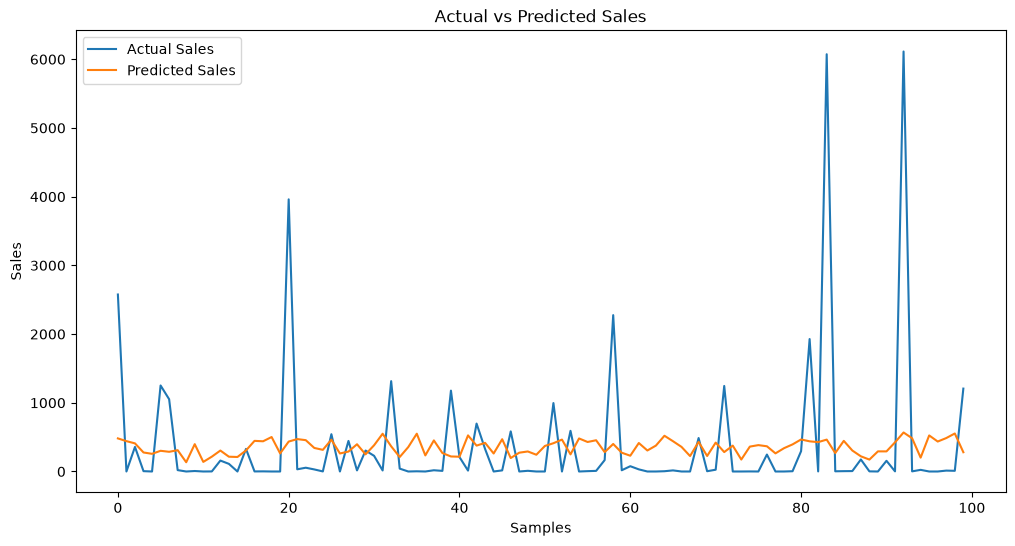

In [27]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(y_pred[:100], label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Samples")
plt.ylabel("Sales")
plt.legend()

plt.show()

# 📉 Step 14: Forecast Error Analysis

Analyze the prediction errors to understand model performance.

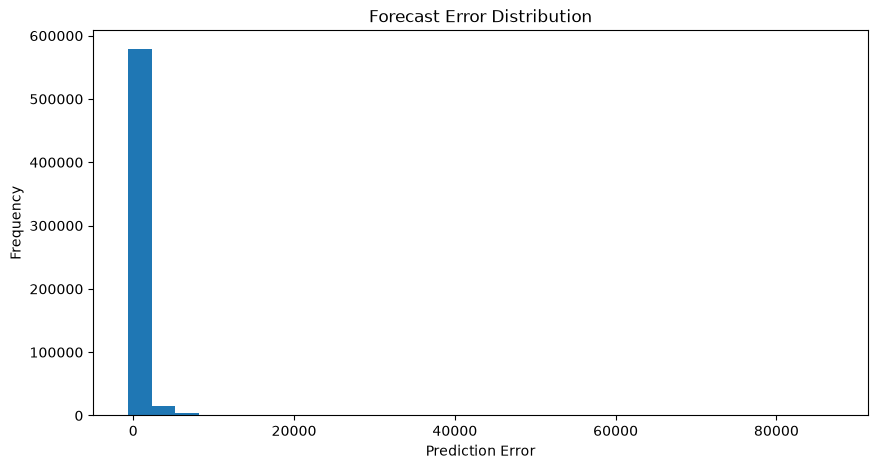

In [28]:
errors = y_test.values - y_pred

plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("Forecast Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

# 💼 Step 15: Business Impact Analysis

### Key Business Benefits

- Improve inventory planning by forecasting demand.
- Reduce stock shortages and overstock situations.
- Support better production and supply chain planning.
- Enable data-driven pricing and promotional strategies.
- Help management make informed business decisions using sales forecasts.

# 🎯 Conclusion

This project successfully demonstrated an end-to-end Sales/Demand Forecasting workflow using historical sales data.

### Workflow Completed

- Data Collection
- Data Exploration
- Time-Based Analysis
- Trend Analysis
- Feature Engineering
- Model Training
- Sales Prediction
- Model Evaluation
- Business Impact Analysis

The forecasting model provides valuable insights into future sales trends and supports better business planning and decision-making.

# 💾 Save Forecast Results

Save the prediction results for future analysis and reporting.

In [29]:
prediction_df.to_csv("sales_forecast_results.csv", index=False)

print("✅ Forecast results saved successfully!")

✅ Forecast results saved successfully!
